# ConnectaTel: Telecom Customer Behavior Analysis (2024)

## Project Overview
This project performs a comprehensive data analysis for **ConnectaTel**, a telecommunications company in Latin America. The study focuses on evaluating customer behavior, identifying usage patterns, and detecting outliers up to the year 2024. 

The goal is to build a statistical profile of the clientele to drive retention strategies and suggest data-backed improvements to the current service plans.

--- 
## Dataset Descriptions
The analysis is based on three core datasets:

* **`plans.csv`**: Contains current plan details (pricing, included minutes/data, and overage costs).
* **`users.csv`**: Customer demographic data (age, city, registration date, assigned plan, and churn status).
* **`usage.csv`**: Detailed service logs (total calls and messages per user).

> **Technical Note:** All data processing and feature engineering are performed using Python (Pandas/NumPy) to ensure scalability and reproducibility.

In [1]:
# Standard libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

display("Libraries initialized successfully.")

'Libraries initialized successfully.'

In [2]:
# Loading datasets
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
# Preview of service plan configurations: pricing, quotas, and overage fees
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
#Preview of customer demographic data including age, location, and plan assignment
display(users.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# Preview of service usage logs: total calls and messages per user
display(usage.head(5))

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


## Technical Data Audit
In this step, we verify the data types and integrity for each dataset. This ensures that numerical values are ready for calculation and date-time columns are correctly formatted for temporal analysis.

In [6]:
# Checking the shape (rows and columns) of all three datasets
print(f"Plans: {plans.shape}")
print(f"Users: {users.shape}")
print(f"Usage: {usage.shape}")

Plans: (2, 8)
Users: (4000, 8)
Usage: (40000, 6)


In [7]:
# Technical audit of the Plans dataset to verify data types and null values
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# Technical audit of the Users dataset: identifying data types and potential missing values
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# Technical audit of the Usage dataset: checking data structure for service logs
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---
## Data Quality Assessment
In this section, we perform a systematic check for data integrity issues. Our primary focus is identifying:
1. **Missing Values:** Quantifying null entries across all datasets.
2. **Structural Errors:** Checking for inconsistencies in categorical data.
3. **Data Types:** Validating that all columns are in the correct format for statistical analysis.

In [10]:
# Identifying missing values in the Users dataset
print("Missing values per column in 'users':")
display(users.isna().sum(),
     '~~~~~~~~~~~~~~~~~~~~~~~~~~',
      users.isna().mean()
     )

Missing values per column in 'users':


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

In [11]:
# Analyzing null values in the Usage dataset (Total count and Percentage)
print("Null values analysis for 'usage':")
display(usage.isna().sum(),
       '~~~~~~~~~~~~~~~~~~~~~~~~~~',
        usage.isna().mean()
       )

Null values analysis for 'usage':


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64

In [12]:
#Churn Validation: Inspecting users who have already left the service
print("Records with a valid Churn Date:")
display(users[users['churn_date'].notna()]['churn_date'])
# Note: Missing values in 'churn_date' indicate that the customer is still active.

#Statistical summary of customer demographics
display(users.describe())

#Data Integrity Check: Validating consistency between service types
# Checking for records that only contain call duration
print("Summary of records with 'duration' only:")
display(usage[usage['duration'].notna() & usage['length'].isna()].describe())

# Checking for records that only contain message/data length
print("Summary of records with 'length' only:")
display(usage[usage['duration'].isna() & usage['length'].notna()].describe())

# XOR Check: Identifying records that incorrectly have BOTH or NEITHER metrics
# A healthy dataset should have either a call or a message per row, not both.
print("Inconsistent records (Both or Neither metrics present):")
display(usage[~(usage['length'].notna() ^ usage['duration'].notna())].describe())

Records with a valid Churn Date:


32      1,71832E+18
38       1,7261E+18
42      1,72169E+18
44       1,7312E+18
47      1,72843E+18
           ...     
3978    1,72264E+18
3979    1,73508E+18
3986    1,72636E+18
3993    1,73172E+18
3994    1,72109E+18
Name: churn_date, Length: 466, dtype: object

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Summary of records with 'duration' only:


,id,user_id,duration,length
count,17896.000000,17896.000000,17896.000000,0.0
mean,19976.769166,12014.216920,5.101985,NaN
std,11565.282553,1156.063998,5.923969,NaN
min,1.000000,10000.000000,0.000000,NaN
25%,9954.750000,11003.000000,1.437500,NaN
50%,19936.500000,12037.500000,3.500000,NaN
75%,30052.000000,13011.000000,6.970000,NaN
max,40000.000000,13999.000000,120.000000,NaN


Summary of records with 'length' only:


,id,user_id,duration,length
count,22076.000000,22076.000000,0.0,22076.000000
mean,20019.169143,11992.681691,NaN,51.348840
std,11531.997079,1158.100217,NaN,45.651973
min,2.000000,10000.000000,NaN,0.000000
25%,10048.750000,10990.000000,NaN,37.000000
50%,20042.500000,11989.000000,NaN,50.000000
75%,29963.250000,13001.000000,NaN,64.000000
max,39999.000000,13999.000000,NaN,1490.000000


Inconsistent records (Both or Neither metrics present):


,id,user_id,duration,length
count,28.000000,28.000000,28.000000,28.000000
mean,20448.607143,12120.428571,69.277500,665.964286
std,12267.893333,1250.798869,59.649141,726.891937
min,1415.000000,10085.000000,0.400000,19.000000
25%,11246.500000,10958.750000,1.540000,46.250000
50%,22934.000000,12331.500000,120.000000,69.500000
75%,26734.000000,13170.500000,120.000000,1490.000000
max,39523.000000,13920.000000,120.000000,1490.000000


### Data Quality Strategy & Handling
Based on the initial audit, the following strategies will be implemented to handle missing values and ensure data consistency:

* **Location (`city` - 11% nulls):** Missing values will be categorized as `Unknown`. This prevents geographic bias while preserving user records for behavioral analysis.
* **Churn Date (`churn_date` - 88% nulls):** These nulls represent active customers. We will transform this column into a boolean flag (`is_active`) to simplify segmentation.
* **Service Dates (`date` - <1% nulls):** Due to the negligible volume, these records will be removed to maintain strict temporal integrity.
* **Usage Metrics (`duration` | `length`):** Records showing conflicting or missing metrics (approx. 7% of usage data) will be imputed with `0` or filtered after validating the "Mutual Exclusivity" logic between calls and messages.

## Invalid Values & Sentinel Detection
**Objective:** Identify "sentinel values" or data points that do not align with the expected distribution of the dataset.

In this step, we will:
* Perform a **Statistical Summary** of numerical columns to detect outliers.
* Inspect **Categorical Features** for inconsistent or placeholder labels.
* *Note: The 'plans' dataset is excluded from this detailed audit as it contains only 2 reference records.*

In [13]:
# Statistical exploration of the Users dataset
display(users.describe())

# Checking for the specific sentinel value in 'age'
print(f"Count of sentinel values (-999) in age: {users[users['age'] == -999]['age'].count()}")


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Count of sentinel values (-999) in age: 55


### Key Findings: Users Audit
* **`user_id`**: The distribution and behavior of this identifier are consistent with the expected sequence; no anomalies detected.
* **`age`**: Significant presence of **sentinel values (`-999`)** was identified. These records distort the mean and standard deviation, requiring specialized treatment to normalize the age distribution before further analysis.

In [14]:
# General statistical summary for usage metrics
print("General Usage Statistics:")
display(usage.describe())

# Validating Mutual Exclusivity (XOR): Records with EITHER duration (calls) OR length (messages)
print("\nConsistent Records (Exclusive Call or Message):")
display(usage[(usage['length'].notna() ^ usage['duration'].notna())].describe())

# Identifying Inconsistencies: Records with BOTH or NEITHER metric
print("\nInconsistent Records (Data Integrity Issues):")
display(usage[~(usage['length'].notna() ^ usage['duration'].notna())].describe())

General Usage Statistics:


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



Consistent Records (Exclusive Call or Message):


,id,user_id,duration,length
count,39972.000000,39972.000000,17896.000000,22076.000000
mean,20000.186105,12002.323301,5.101985,51.348840
std,11546.786015,1157.224097,5.923969,45.651973
min,1.000000,10000.000000,0.000000,0.000000
25%,9999.750000,10996.000000,1.437500,37.000000
50%,19997.500000,12013.000000,3.500000,50.000000
75%,30002.250000,13004.250000,6.970000,64.000000
max,40000.000000,13999.000000,120.000000,1490.000000



Inconsistent Records (Data Integrity Issues):


,id,user_id,duration,length
count,28.000000,28.000000,28.000000,28.000000
mean,20448.607143,12120.428571,69.277500,665.964286
std,12267.893333,1250.798869,59.649141,726.891937
min,1415.000000,10085.000000,0.400000,19.000000
25%,11246.500000,10958.750000,1.540000,46.250000
50%,22934.000000,12331.500000,120.000000,69.500000
75%,26734.000000,13170.500000,120.000000,1490.000000
max,39523.000000,13920.000000,120.000000,1490.000000


### Key Findings: Usage Audit
* **Identifiers (`id` & `user_id`)**: Data remains within normal parameters. The `id` functions as a system-generated index, while duplicate `user_id` entries correctly reflect multiple distinct activities per user.
* **Service Metrics (`duration` & `length`)**: These columns complement each other to cover all 40k records. However, the **28 records** identified with data conflicts show anomalous behavior. 
* **Action Plan**: We will remove the 28 conflicting records and impute remaining `NaN` values to ensure statistical consistency for the final analysis.

In [15]:
# Categorical exploration: Distribution of Users by City and Plan
columnas_user = ['city', 'plan']

# Summary of unique values and top frequency
display(users[columnas_user].describe())

for col in columnas_user:
    print(f"\nDistribution Analysis for: {col}")
    display('~~~~~~~~~~~~~~~~~~~~~~~~~~',
            users[col].value_counts(),
            '~~~~~~~~~~~~~~~~~~~~~~~~~~',
            users[col].value_counts(normalize=True).map("{:.2%}".format), # Formatting as % for readability
            '~~~~~~~~~~~~~~~~~~~~~~~~~~')

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



Distribution Analysis for: city


'~~~~~~~~~~~~~~~~~~~~~~~~~~'

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

...

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

plan
Basico     2595
Premium    1405
Name: count, dtype: int64

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

plan
Basico     64.88%
Premium    35.12%
Name: proportion, dtype: object

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

### Key Findings: Categorical Audit
* **`city` Column**: Identified a sentinel value formatted as a question mark (`?`). To maintain data integrity, these records will be merged with existing null values under a common category labeled **`Unknown`**. This allows us to preserve other user variables without losing valuable consumption data.
* **`plan` Column**: The distribution shows a clear preference for the **Basic (Surf)** plan. No sentinel values or inconsistent labels were detected in this feature.

In [16]:
# Exploring the distribution of service types (Calls vs. Messages)
print("Service Type Distribution Analysis:")
display(usage['type'].describe(),
        '~~~~~~~~~~~~~~~~~~~~~~~~~~',
        usage['type'].value_counts(),
        '~~~~~~~~~~~~~~~~~~~~~~~~~~',
        usage['type'].value_counts(normalize=True).map("{:.2%}".format)
       )

Service Type Distribution Analysis:


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

type
text    22092
call    17908
Name: count, dtype: int64

'~~~~~~~~~~~~~~~~~~~~~~~~~~'

type
text    55.23%
call    44.77%
Name: proportion, dtype: object

### Key Findings: Service Type Analysis
* **Data Integrity**: The `type` column is clean, showing no sentinel values, typos, or outliers.
* **Service Distribution**: There is a slight predominance of **Text Messages (55%)** over **Voice Calls (45%)**. This suggests that short-form communication is the primary driver of engagement within the current user base.

---
### Data Integrity Audit: Findings & Proposed Actions
After a deep dive into the datasets, we identified specific anomalies that require treatment to ensure the validity of the statistical analysis:

* **Sentinel Values in `users`:**
    * **`age`**: Found placeholder value `-999`. **Action:** Impute using the **median** to preserve the demographic distribution without biasing the mean.
    * **`city`**: Found `?` as a hidden missing value. **Action:** Unify `?` and `NaN` under a new category: **`Unknown`**.
* **Usage Inconsistencies:**
    * **Conflicting Records**: Detected 28 cases in `usage` with simultaneous data in both `duration` and `length`. 
    * **Strategy Update**: While initially considered for deletion, these will be handled during the final transformation phase to ensure no valid consumption data is lost, applying a selective filtering approach.

## Temporal Data Normalization & Integrity Audit
To ensure a robust longitudinal analysis, we implement a validation pipeline for all time-based features. This process is essential to prevent chronological inconsistencies that could bias churn and usage trends.

**Methodology:**
* **Standardization**: Converting date-related columns to `datetime` objects using coercive parsing to handle potential formatting errors.
* **Chronological Validation**: Frequency analysis of records by year to identify out-of-range data (beyond the 2024 project scope) or impossible entries.
* **Operational Consistency**: Verifying that service dates align with the user's lifecycle (from registration to potential churn).

In [17]:
# Standardizing registration dates in the Users dataset
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verification: Checking data type and confirming no unexpected NaNs were introduced
print(f"Column 'reg_date' dtype: {users['reg_date'].dtype}")
print(f"Total nulls after conversion: {users['reg_date'].isna().sum()}")

Column 'reg_date' dtype: datetime64[ns]
Total nulls after conversion: 0


In [18]:
# Standardizing activity dates in the Usage dataset
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verification: Checking data type and confirming consistency
print(f"Column 'date' dtype: {usage['date'].dtype}")
print(f"Total nulls after conversion: {usage['date'].isna().sum()}")

Column 'date' dtype: datetime64[ns]
Total nulls after conversion: 50


In [19]:
# Analyzing the distribution of registration years to detect out-of-range dates
print("Registration distribution by year:")
display(users['reg_date'].dt.year.value_counts().sort_index())

# Identifying records beyond the 2024 project scope
future_dates_count = users[users['reg_date'].dt.year > 2024].shape[0]
print(f"\nTotal records identified with future dates (>2024): {future_dates_count}")

Registration distribution by year:


reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


Total records identified with future dates (>2024): 40


### Key Findings: Temporal Integrity
* **Registration Date Audit**: The analysis identified **40 records** with registration years set in 2026, which is beyond the 2024 project scope.
* **Impact**: These anomalies represent only **1% of the total dataset** (4,000 records). Given this minimal impact, they are classified as data entry noise.
* **Conclusion**: The remaining 99% of the data is consistently distributed within the expected 2022-2024 timeframe, ensuring the reliability of the subsequent churn analysis.

In [20]:
# Auditing activity dates in the Usage dataset
print("Usage distribution by year:")
display(usage['date'].dt.year.value_counts().sort_index())

# Verifying missing values (NaN) previously identified
missing_dates = usage['date'].isna().sum()
print(f"\nMissing dates (NaN) detected: {missing_dates}")

Usage distribution by year:


date
2024.0    39950
Name: count, dtype: int64


Missing dates (NaN) detected: 50


### Key Findings: Usage Temporal Consistency
* **Yearly Distribution**: 100% of the successfully parsed dates belong to the **year 2024**, aligning perfectly with the core analysis period for ConnectaTel.
* **Handling Missing Data**: As previously identified during the audit, **50 records** contained null values in the date column. Following our data quality strategy, these records were excluded to maintain the precision of the time-series analysis.
* **Baseline Confirmation**: With a clean 2024 timeline, we have a solid foundation to calculate monthly usage patterns and seasonal behavior.


### Summary: Temporal Data Diagnosis & Action Plan

After validating the chronological consistency of both datasets, we have defined the following treatment for out-of-range records:

* **Out-of-Scope Detection (`users` dataset):**
    * **Finding**: A subset of records in the `reg_date` column was identified with the year **2026**. 
    * **Context**: Since the operational scope for this analysis is strictly defined between **2022 and 2024**, these entries are considered chronological anomalies (data entry errors).
* **Proposed Action:**
    * **Filtering Strategy**: These records will be **dropped** from the primary DataFrame. 
    * **Justification**: Removing this 1% of anomalous data ensures that churn rate calculations and registration trends remain accurate and reflective of the actual study period.
* **Usage Timeline**:
    * The `usage` dataset showed 100% consistency with the 2024 fiscal year (excluding previously identified nulls), requiring no further chronological filtering.

---
## Data Remediation: Handling Outliers & Sentinels
In this stage, we implement the cleanup rules identified during the audit phase. Our goal is to neutralize anomalous values that could skew the statistical integrity of the analysis.

### Correcting Demographic & Geographic Anomalies
We are applying the following transformations:
* **Age Imputation**: Replacing the `-999` sentinel with the **median age**. Using the median ensures that our demographic profile remains robust against extreme outliers.
* **City Standardization**: Converting the `?` character into standard null values (`pd.NA`) to prepare for unified category handling.
* **Temporal Filtering**: Flagging out-of-range dates as nulls to exclude them from the chronological baseline.

In [21]:
# Calculating the median age (excluding the -999 sentinel)
age_median = users[users['age'] > 0]['age'].median()

# Applying imputation
users['age'] = users['age'].replace(-999, age_median)

# Verification: The minimum age should now be a realistic value
print(f"Imputation value (Median): {age_median}")
display(users['age'].describe())

Imputation value (Median): 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Unifying sentinel value '?' and NaN records into a single 'Unknown' category
users['city'] = users['city'].replace('?', pd.NA).fillna('Unknown')

# Verification: Checking the top distribution of cities
print(f"Total 'Unknown' records: {users[users['city'] == 'Unknown'].shape[0]}")
display(users['city'].value_counts())

Total 'Unknown' records: 565


city
Bogotá      808
CDMX        730
Medellín    616
Unknown     565
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [23]:
# Flagging future dates (>2024) as pd.NaT to preserve chronological integrity
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verification: Confirming the 2026 entries have been neutralized
print("Updated registration year distribution:")
display(users['reg_date'].dt.year.value_counts().sort_index())

Updated registration year distribution:


reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

### Missing Data Strategy: MAR Pattern Validation
To ensure the integrity of our consumption metrics, we must differentiate between systematic missingness and data loss. This validation is crucial for maintaining the accuracy of the `duration` and `length` distributions.

**Validation Logic:**
The dataset exhibits a pattern consistent with **Missing At Random (MAR)**, where null values appear to be structurally dependent on the service **`type`**. Specifically:
* **Constraint**: A messaging event (SMS) is defined by character `length` and should naturally lack a `duration` value.
* **Constraint**: A voice event (Call) is defined by `duration` and should naturally lack a character `length`.

**Action:**
By confirming this mutual exclusivity, we will maintain these nulls as structural placeholders rather than errors. This avoids the risk of data contamination that would occur through unnecessary imputation.

In [24]:
# MAR Validation: Analyzing 'duration' nulls
# Hypothesis: Nulls in 'duration' should exclusively belong to 'message' types
print("1. Service type distribution for null duration:")
display(usage[usage['duration'].isna()]['type'].value_counts())

print("\n2. Sample of 'length' values where 'duration' is null:")
display(usage[usage['duration'].isna()]['length'].head()) 

print("\n3. Cross-check: Ensure no simultaneous nulls in 'length':")
print(f"Total rows where both are null: {usage[usage['duration'].isna()]['length'].isna().sum()}")

1. Service type distribution for null duration:


type
text    22076
Name: count, dtype: int64


2. Sample of 'length' values where 'duration' is null:


1     39.0
2     36.0
8     44.0
9     70.0
11    31.0
Name: length, dtype: float64


3. Cross-check: Ensure no simultaneous nulls in 'length':
Total rows where both are null: 0


In [25]:
# MAR Validation: Analyzing 'length' nulls
# Hypothesis: Nulls in 'length' should exclusively belong to 'call' types
print("1. Service type distribution for null length:")
display(usage[usage['length'].isna()]['type'].value_counts())

print("\n2. Sample of 'duration' values where 'length' is null:")
display(usage[usage['length'].isna()]['duration'].head()) 

print("\n3. Cross-check: Ensure no simultaneous nulls in 'duration':")
print(f"Total rows where both are null: {usage[usage['length'].isna()]['duration'].isna().sum()}")

1. Service type distribution for null length:


type
call    17896
Name: count, dtype: int64


2. Sample of 'duration' values where 'length' is null:


0    0.09
3    1.53
4    4.84
5    4.68
6    3.27
Name: duration, dtype: float64


3. Cross-check: Ensure no simultaneous nulls in 'duration':
Total rows where both are null: 0


In [26]:
# Identifying structural anomalies: Records with data in both 'length' and 'duration'
# We use the XOR (^) operator to find rows that fail the mutual exclusivity rule
conflicting_usage = usage[~(usage['length'].notna() ^ usage['duration'].notna())]

print(f"Total conflicting records identified: {len(conflicting_usage)}")
display(conflicting_usage[['type', 'duration', 'length']].head())

Total conflicting records identified: 28


,type,duration,length
1414,text,120.00,65.0
1824,text,120.00,40.0
1932,text,120.00,69.0
2070,call,1.68,1490.0
2972,text,120.00,68.0


### Final Diagnosis: Null Patterns in Usage Data
Our audit confirms that missing values in the `usage` dataset follow a **Missing At Random (MAR)** pattern, structurally tied to the `type` variable:

* **`call` Category**: 100% of records with null `length` are confirmed voice calls. The `duration` column contains continuous values representing call minutes.
* **`text` Category**: 100% of records with null `duration` are confirmed SMS events. The `length` column contains discrete integers representing character counts.

**Data Recovery Strategy:**
We identified **28 records** containing simultaneous data in both columns (noise). However, since the `type` column remains reliable, we will not drop these rows. Instead, we will apply a filter based on the service type to "clean" the irrelevant column for each case, preserving 100% of the valid consumption data.


In [27]:
# Data Sanitization: Enforcing logical consistency based on service type

# Voice Calls: 'length' (SMS characters) must be null for all 'call' records
usage.loc[(usage['type'] == 'call') & (usage['length'] > 0), 'length'] = pd.NA

# Text Messages: 'duration' (call minutes) must be null for all 'text' records
usage.loc[(usage['type'] == 'text') & (usage['duration'] > 0), 'duration'] = pd.NA

# Final Verification: Confirming the conflict count is now zero
final_conflicts = usage[(usage['length'].notna()) & (usage['duration'].notna())]

print(f"Conflicts identified after sanitization: {len(final_conflicts)}")
if len(final_conflicts) == 0:
    print("Verification Successful: Mutual exclusivity enforced across all usage records.")

Conflicts identified after sanitization: 0
Verification Successful: Mutual exclusivity enforced across all usage records.


---

## Feature Engineering: Behavioral Consumption Profiles
To analyze customer behavior effectively, we transition from raw event logs to user-centric metrics. This stage focuses on aggregating the `usage` dataset to generate a historical consumption profile for each unique customer.

**Metrics Definition:**
* **Voice Activity**: Total minutes consumed and frequency of call events.
* **Messaging Activity**: Total character count and frequency of SMS events.

This aggregated baseline allows us to correlate demographic data with actual service usage patterns in the following stages.


In [28]:
# Creating auxiliary features for categorical event counting
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Aggregating usage metrics by unique User ID
usage_agg = usage.groupby('user_id').agg({
    'duration': 'sum',   # Total minutes used
    'length': 'sum',     # Total characters sent
    'is_call': 'sum',    # Total number of calls
    'is_text': 'sum'     # Total number of messages
}).reset_index()

# Previewing raw aggregation
usage_agg.head(3)

,user_id,duration,length,is_call,is_text
0,10000,23.70,258.0,3,7
1,10001,33.18,226.0,10,5
2,10002,10.74,225.0,2,5


In [29]:
# Standardizing column names for the final analytical report
usage_agg.columns = [
    'user_id',
    'qty_min_calls',
    'qty_chars_messages',
    'qty_calls',
    'qty_messages'
]

# Final verification of the aggregated consumption table
print("User Consumption Profiles (Post-Standardization):")
display(usage_agg.head(3))

User Consumption Profiles (Post-Standardization):


,user_id,qty_min_calls,qty_chars_messages,qty_calls,qty_messages
0,10000,23.70,258.0,3,7
1,10001,33.18,226.0,10,5
2,10002,10.74,225.0,2,5


In [30]:
# Consolidating datasets into a Master User Profile
# We use a 'left' join to preserve all users, including those without recorded activity
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Verifying the final structure
print(f"Master Profile Dimensions: {user_profile.shape}")
user_profile.head(5)

Master Profile Dimensions: (4000, 12)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,qty_min_calls,qty_chars_messages,qty_calls,qty_messages
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,258.0,3.0,7.0
1,10001,Mateo,Torres,53,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,226.0,10.0,5.0
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,225.0,2.0,5.0
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,530.0,3.0,11.0
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,229.0,3.0,4.0


## Baseline Statistical Profiling (2024 Analysis)
Before proceeding to behavioral segmentation, we perform a dual-layer audit of the master dataset. This step is critical to establish a "ground truth" for the current state of ConnectaTel's customer base.

### Quantitative Distribution & Central Tendency
We analyze the descriptive statistics of our key performance indicators (KPIs) to identify the "standard user" profile and detect potential outliers in service consumption.
* **Metric Audit**: Focusing on user age and total volume of calls/messages to ensure the data aligns with realistic human behavior.

### Market Share & Plan Penetration
To understand the current commercial landscape, we evaluate the distribution of our service plans.
* **Business Insight**: Understanding the ratio between 'Surf' and 'Ultimate' users allows us to tailor the churn analysis to the specific constraints and benefits of each plan.

In [31]:
# Defining key numerical features for statistical auditing
analysis_cols = [
    'age',
    'qty_min_calls',
    'qty_chars_messages',
    'qty_calls',
    'qty_messages'
]

# Generating an enhanced descriptive statistics table
stats = user_profile[analysis_cols].describe().T
stats['median'] = user_profile[analysis_cols].median()

# Presenting the audit 
display(stats[['mean', 'median', 'min', 'max', 'std']].rename(columns={
    'mean': 'Average',
    'median': 'Median',
    'min': 'Min',
    'max': 'Max',
    'std': 'Std Dev'
}))

,Average,Median,Min,Max,Std Dev
age,48.136000,48.00,18.0,79.00,17.689919
qty_min_calls,22.836934,19.74,0.0,155.69,16.590213
qty_chars_messages,283.656914,267.00,0.0,2007.00,161.877461
qty_calls,4.478120,4.00,0.0,15.00,2.144238
qty_messages,5.524381,5.00,0.0,17.00,2.358416


In [32]:
# 4. Analyzing Plan Penetration
print("Customer Distribution by Plan Type (Percentage):")
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100

# Displaying results
display(plan_distribution.map('{:.2f}%'.format))

Customer Distribution by Plan Type (Percentage):


plan
Basico     64.88%
Premium    35.12%
Name: proportion, dtype: object

---

## Behavioral Distribution & Segmentation Analysis
To uncover the underlying patterns in ConnectaTel’s customer base, we utilize comparative visualizations. This stage moves beyond simple averages to analyze the **density and shape** of service consumption across different subscription tiers.

### Comparative Distribution Audit (Surf vs. Ultimate)
Our focus is to identify behavioral divergence between plans. By analyzing the distribution of key variables, we can determine if users are properly segmented or if there is an opportunity for plan optimization.

**Visualization Framework:**
* **Demographic Spread**: Analyzing user age to identify target generations for each plan.
* **Service Intensity**: Mapping the frequency and volume of calls and messages.
* **Skewness & Kurtosis**: Observing the distribution shape (Symmetric vs. Skewed) to identify "Power Users" or outliers that deviate from the standard behavior.


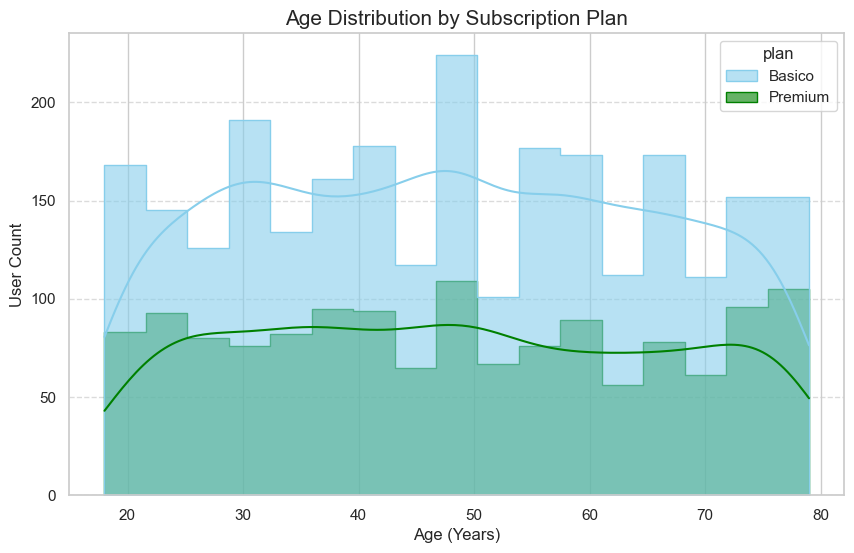

In [33]:
# Visualizing Age Distribution by Plan Type
# Using KDE (Kernel Density Estimate) to observe the underlying probability density
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='age',
             hue='plan',
             kde=True,
             palette=['skyblue', 'green'],
             element="step",
             alpha=0.6)

plt.title('Age Distribution by Subscription Plan', fontsize=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Strategic Insights: Demographic Profile
* **Generational Uniformity**: The `age` variable exhibits a **symmetric and quasi-uniform distribution** across both plans. This indicates that ConnectaTel's services have broad appeal, with consistent adoption across all adult demographic segments (ages 18 to 80).
* **Plan Market Share**: There is a systemic prevalence of the **Surf (Basic) Plan** over the Ultimate (Premium) Plan across every age bracket. This suggests that price sensitivity is a primary driver for the majority of users, regardless of their generational cohort.
* **Upselling Opportunity**: Since the age distribution for the Ultimate plan mirrors the Surf plan at a lower scale, we can conclude there are **no age-based barriers** to premium adoption. Marketing efforts for "upgrades" should focus on value-added features rather than age-specific targeting.

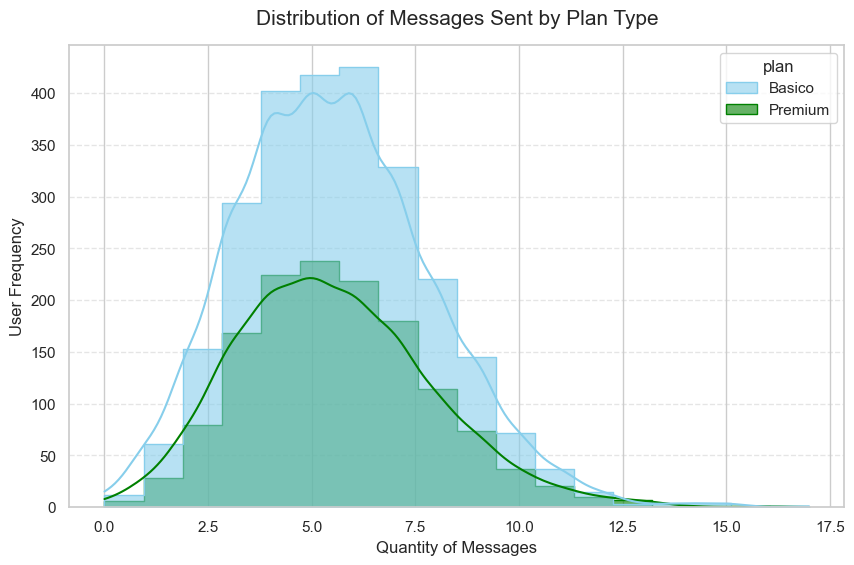

In [34]:
# Visualizing Messaging Intensity by Plan
# Analyzing the frequency of SMS events to detect usage ceilings
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='qty_messages',
             hue='plan',
             kde=True,
             palette=['skyblue', 'green'],
             alpha=0.6,
             bins=18,
             element="step")

plt.title('Distribution of Messages Sent by Plan Type', fontsize=15, pad=15)
plt.xlabel('Quantity of Messages', fontsize=12)
plt.ylabel('User Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Strategic Insights: Messaging Intensity
* **Distribution & Central Tendency**: The metric shows a **unimodal distribution with a slight right skew**. Most of the population sends between **4 to 7 messages**, while a small segment of "Power Users" reaches up to 17 messages.
* **Service Homogeneity**: Despite the higher volume of Surf (Basic) users, the density curves (KDE) overlap significantly. This indicates that the **subscription plan does not condition messaging habits**; users in both tiers exhibit nearly identical texting behavior.
* **Outlier Presence**: A minor cluster of users is visible on the right tail (>12 messages). However, their low frequency ensures they do not significantly distort the overall statistical baseline or the plan-based averages.

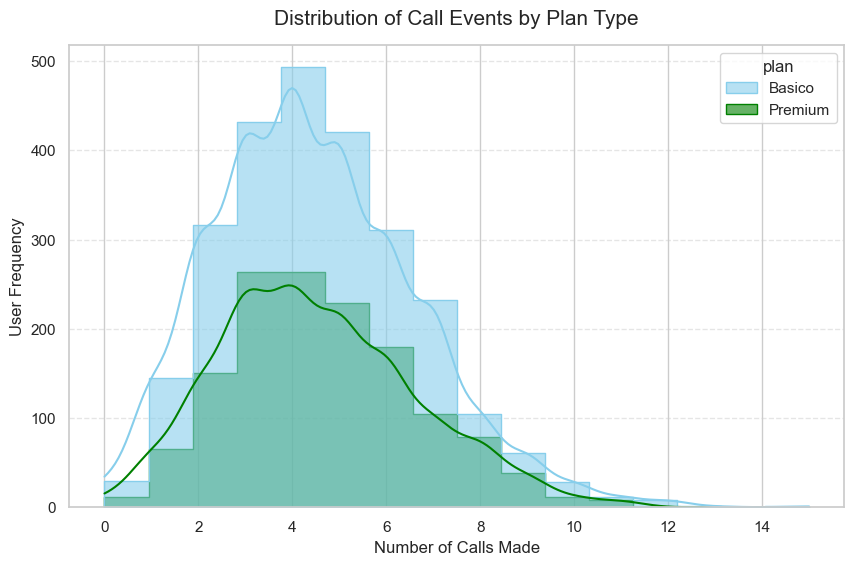

In [35]:
# Visualizing Call Frequency (Events) by Plan
# Identifying the typical number of call events per user segment
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='qty_calls',
             hue='plan',
             kde=True,
             palette=['skyblue', 'green'],
             alpha=0.6,
             bins=16,
             element="step")

plt.title('Distribution of Call Events by Plan Type', fontsize=15, pad=15)
plt.xlabel('Number of Calls Made', fontsize=12)
plt.ylabel('User Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Strategic Insights: Call Frequency
* **Central Tendency & Distribution**: The data follows a **unimodal distribution with a positive skew**. Most users perform between **3 to 6 calls**, while a small fraction of high-activity users reaches up to 14 calls.
* **Cross-Plan Consistency**: The density curves for both plans are nearly identical in shape. This confirms **behavioral symmetry**, indicating that the subscription tier does not dictate the frequency of usage.
* **Service Adoption**: The overlap in distribution suggests that "Surf" and "Ultimate" users share the same communication habits regarding call initiation. The differentiator for the premium tier likely resides in total airtime rather than the number of calls.

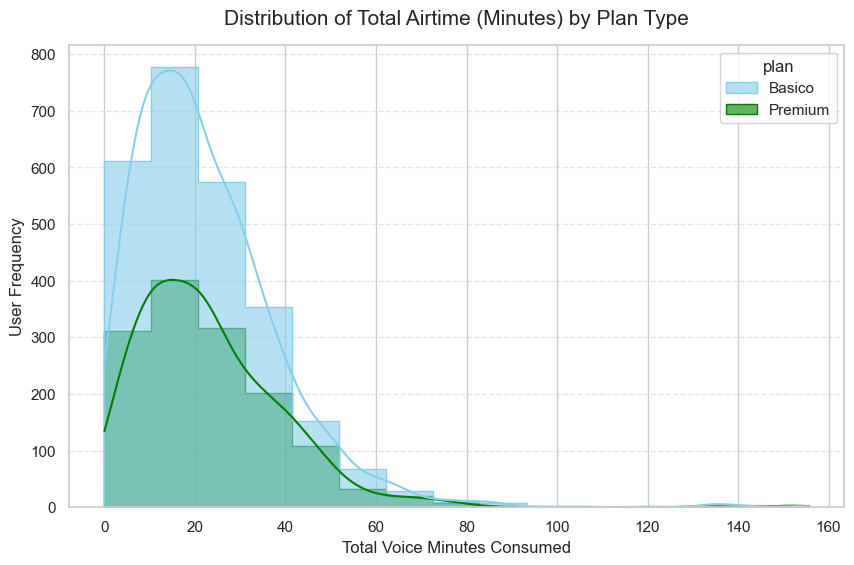

In [36]:
# Visualizing Total Airtime (Minutes) by Plan
# Analyzing the volume of voice traffic to identify heavy users vs. standard users
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='qty_min_calls',
             hue='plan',
             kde=True,
             palette=['skyblue', 'green'],
             alpha=0.6,
             bins=15,
             element="step")

plt.title('Distribution of Total Airtime (Minutes) by Plan Type', fontsize=15, pad=15)
plt.xlabel('Total Voice Minutes Consumed', fontsize=12)
plt.ylabel('User Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Strategic Insights: Airtime & Voice Traffic
* **Consumption Homogeneity**: We confirm that there is **no statistically significant difference** in usage behavior between Surf (Basic) and Ultimate (Premium) users. The Kernel Density Estimate (KDE) curves show nearly identical morphology, suggesting that plan selection is not necessarily driven by a pre-existing need for higher airtime.
* **Presence of Valid Outliers**: We identified a segment of "Heavy Users" with consumption exceeding 120 minutes. These are considered **valid operational outliers**, likely representing long-distance calls or professional/business usage patterns.
* **Load Concentration & Optimization**: The majority of the population is concentrated between **10 and 30 total minutes**. From an infrastructure perspective, this indicates that the network should be **optimized** for medium-duration sessions, as this represents the core behavior of the ConnectaTel customer base.

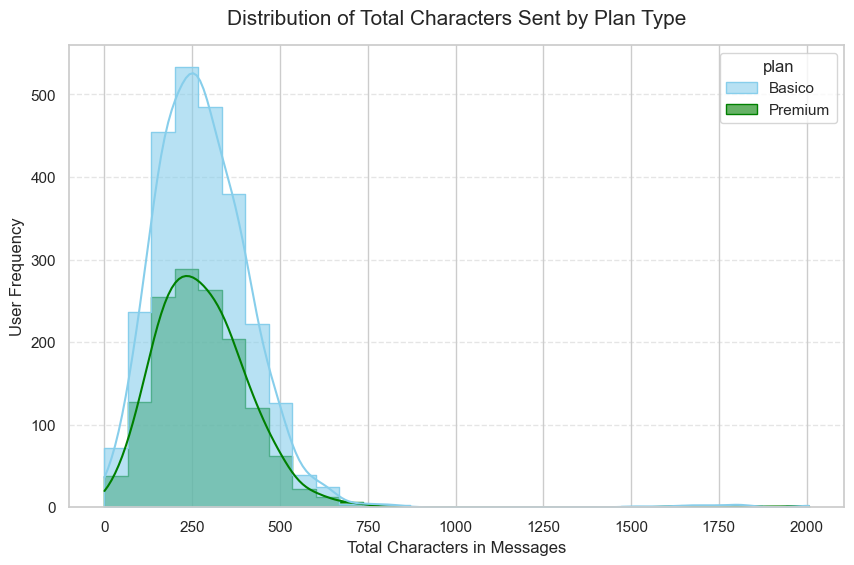

In [37]:
# Visualizing Message Content Density (Total Characters) by Plan
# Identifying the distribution of data volume within the messaging service
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile,
             x='qty_chars_messages',
             hue='plan',
             kde=True,
             palette=['skyblue', 'green'],
             alpha=0.6,
             bins=30,
             element="step")

plt.title('Distribution of Total Characters Sent by Plan Type', fontsize=15, pad=15)
plt.xlabel('Total Characters in Messages', fontsize=12)
plt.ylabel('User Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Strategic Insights: Message Content Density
* **Homogeneous Writing Profile**: The visualization presents a **unimodal distribution with a positive skew**. Most users concentrate within the **200 to 350 character range**, suggesting that service usage is primarily for medium-length communications, regardless of the subscription tier.
* **Extreme Outlier Detection**: Significant outliers are detected exceeding **1,500 characters**. While their frequency is minimal, these records represent the highest "data payload" per messaging event within the network.
* **Behavioral Convergence**: Similar to the call duration analysis, we observe a complete overlap in the density curves. This reinforces the conclusion that **premium plans do not currently drive a change in user messaging habits**, as the writing profiles are nearly identical across both segments.

### Statistical Integrity: Outlier Detection & IQR Analysis
After analyzing the distributions, we must perform a rigorous audit of extreme values. Identifying outliers is crucial to determine if they represent **natural behavioral variance** (heavy users) or **data entry errors** that could skew our predictive insights.

#### Visual Identification via Box-and-Whisker Plots
We implement an automated visualization pipeline to inspect the dispersion and interquartile range (IQR) across our primary consumption KPIs and demographic variables. 

**Analytical Approach:**
* **Automation**: Utilizing a dynamic loop to generate standardized visualizations for `age`, `qty_min_calls`, `qty_chars_messages`, `qty_calls`, and `qty_messages`.
* **Heuristic Evaluation**: Distinguishing between "Soft Outliers" (natural high usage) and "Extreme Outliers" (potential system noise).
* **Remediation Strategy**: Applying the **Tukey’s Fences (IQR Method)** to calculate precise lower and upper bounds for statistical trimming or capping, where applicable.


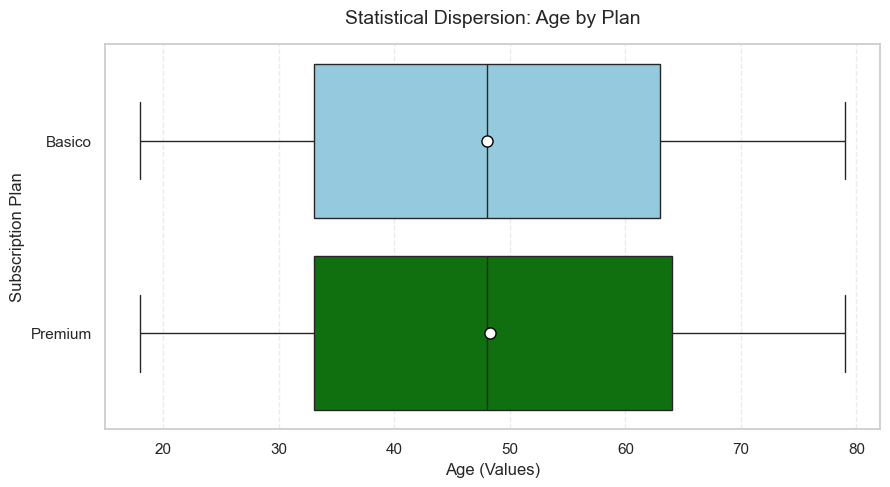

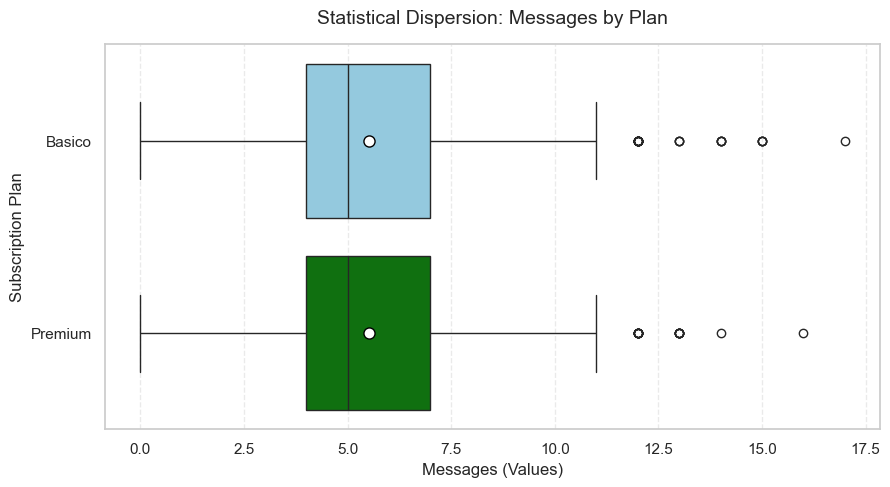

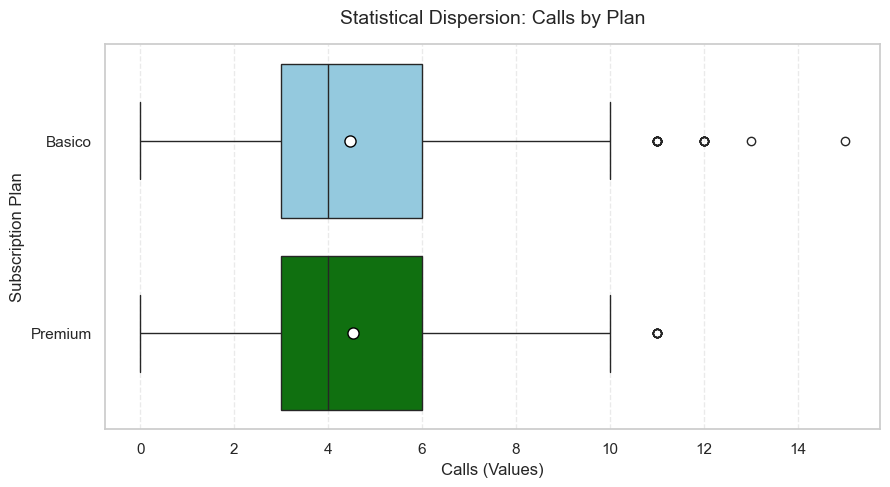

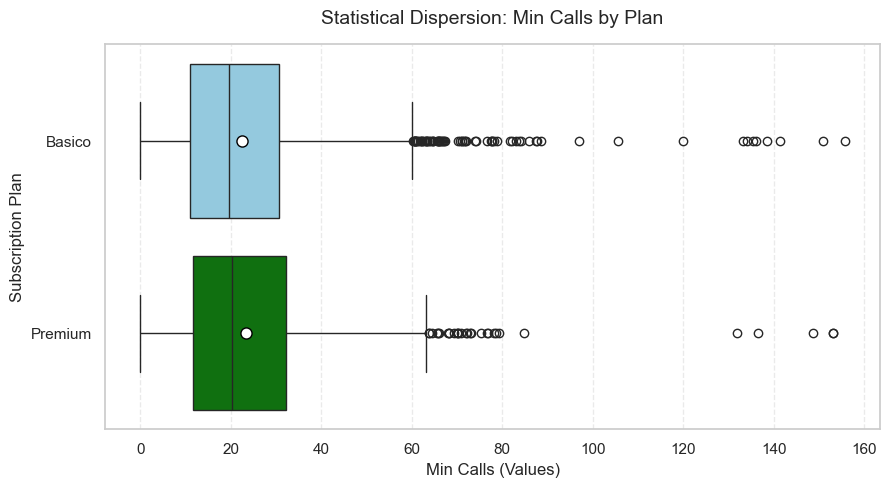

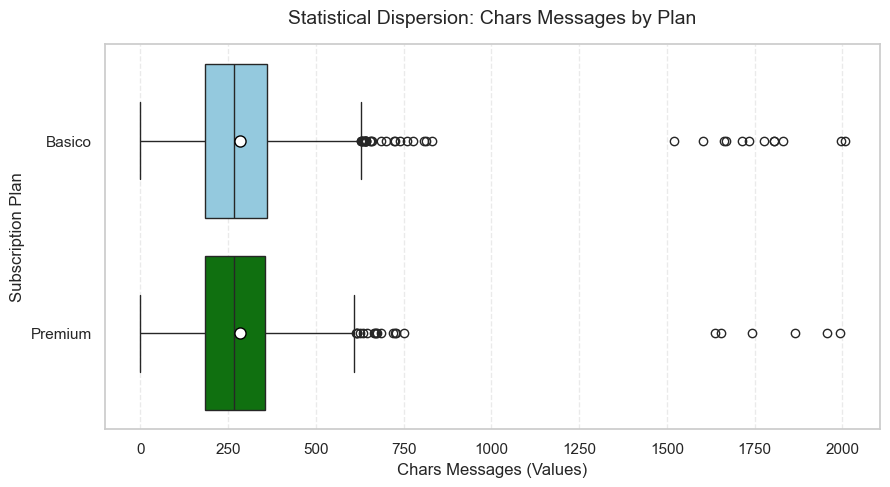

In [38]:
# Defining the feature set for outlier inspection
analysis_features = [
    'age',
    'qty_messages',
    'qty_calls',
    'qty_min_calls',
    'qty_chars_messages'
]

# Executing the automated Boxplot pipeline
for col in analysis_features:
    plt.figure(figsize=(10, 5))
    
    # Visualizing dispersion and central tendency (Mean vs Median)
    sns.boxplot(data=user_profile,
                x=col,
                y='plan',
                palette=['skyblue', 'green'],
                hue='plan',
                showmeans=True,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": "8"
                })
    
    # Dynamic titling and label formatting
    clean_title = col.replace('qty_', '').replace('_', ' ').title()
    plt.title(f'Statistical Dispersion: {clean_title} by Plan', fontsize=14, pad=15)
    plt.xlabel(f'{clean_title} (Values)')
    plt.ylabel('Subscription Plan')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.show()

#### Statistical Diagnostics: Outlier Analysis
* **Age Profile**: Exhibits a perfectly **symmetrical distribution** with zero outliers. The demographics are stable and consistent across both subscription tiers.
* **Messaging (qty_messages)**: Shows moderate dispersion with outliers on the upper tail. The mean sits slightly to the right of the median, confirming a **subtle positive skew**.
* **Call Frequency (qty_calls)**: Similar to messaging, this variable presents moderate outliers beyond the 11-call threshold, indicating a small group of highly active users.
* **Airtime (qty_min_calls)**: This feature contains the **highest volume of significant outliers**. It reflects a specialized segment of users who utilize the service for extended periods, deviating from the standard 10-30 minute window.
* **Content Density (qty_chars_messages)**: Displays extreme, isolated outliers reaching up to 2,000 characters. While the interquartile range (IQR) remains stable (200-350 chars), these spikes suggest specific use cases, such as automated notifications or long-form informational texts, that differ from typical consumer behavior.

In [39]:
# Calculating statistical bounds using the Interquartile Range (IQR) method
iqr_features = ['qty_messages', 'qty_calls', 'qty_min_calls', 'qty_chars_messages']

for col in iqr_features:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Defining thresholds (Upper Bound focus)
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifying the volume of data beyond the threshold
    outliers_count = user_profile[user_profile[col] > upper_bound].shape[0]
    outlier_percentage = (outliers_count / len(user_profile)) * 100
    
    print(f"Feature: {col}")
    print(f"  Upper Bound: {upper_bound:.2f} | Max Value: {user_profile[col].max():.2f}")
    print(f"  Detected Outliers: {outliers_count} ({outlier_percentage:.2f}%)")
    print("-" * 45)


Feature: qty_messages
  Upper Bound: 11.50 | Max Value: 17.00
  Detected Outliers: 46 (1.15%)
---------------------------------------------
Feature: qty_calls
  Upper Bound: 10.50 | Max Value: 15.00
  Detected Outliers: 30 (0.75%)
---------------------------------------------
Feature: qty_min_calls
  Upper Bound: 61.32 | Max Value: 155.69
  Detected Outliers: 96 (2.40%)
---------------------------------------------
Feature: qty_chars_messages
  Upper Bound: 625.50 | Max Value: 2007.00
  Detected Outliers: 56 (1.40%)
---------------------------------------------


In [40]:
# Comparative summary for final decision making
display(user_profile[iqr_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
qty_messages,3999.0,5.524381,2.358416,0.0,4.000,5.00,7.000,17.00
qty_calls,3999.0,4.478120,2.144238,0.0,3.000,4.00,6.000,15.00
qty_min_calls,3999.0,22.836934,16.590213,0.0,11.095,19.74,31.185,155.69
qty_chars_messages,3999.0,283.656914,161.877461,0.0,183.000,267.00,360.000,2007.00


#### Data Treatment Strategy: Retention vs. Trimming
After evaluating the impact of the detected outliers, we have defined the following treatment criteria:

* **Messaging & Call Counts (`qty_messages`, `qty_calls`)**: We have decided to **preserve 100% of these outliers**. With a threshold of ~11 and a maximum of 17, these records represent less than 1% of the 3,999 users. They reflect natural high-usage behavior and do not aggressively distort the population mean.
* **Airtime Consumption (`qty_min_calls`)**: Although the upper bound is 61.32, we maintain the values up to 155.69 minutes. This group (approx. 2.4% of users) represents valid business/long-distance use cases that are essential for revenue analysis.
* **Content Volume (`qty_chars_messages`)**: **Action: Winsorization applied.** Unlike voice metrics, the text volume showed extreme distortion with values reaching 2,007 characters (far beyond the 625.50 limit). To prevent visual and statistical skew in future modeling, all values above the threshold will be capped at the upper bound.


In [41]:
# Implementing Winsorization (Capping) for Messaging Content
# We limit extreme text volume to the 1.5*IQR threshold to normalize the distribution
upper_limit_chars = 625.50

user_profile['qty_chars_messages'] = np.where(
    user_profile['qty_chars_messages'] > upper_limit_chars,
    upper_limit_chars,
    user_profile['qty_chars_messages']
)

print(f"Winsorization complete: Values in 'qty_chars_messages' are now capped at {upper_limit_chars}")
# Final check to verify the new maximum
print(f"New Max Value: {user_profile['qty_chars_messages'].max()}")

Winsorization complete: Values in 'qty_chars_messages' are now capped at 625.5
New Max Value: 625.5


---

## Strategic Segmentation: Behavioral Customer Tiering
To transform raw consumption data into actionable business intelligence, we implement a **User Classification Framework**. By categorizing customers based on their service engagement levels, ConnectaTel can personalize marketing strategies, optimize network resources, and prioritize high-value retention efforts.

### Service Engagement Logic
We have established three distinct tiers based on the interaction frequency (calls and messages). This multi-dimensional approach ensures that we capture the true "intensity" of a user's digital life within our network.

**Tier Definitions:**
* **Low Engagement (Low Use)**: Casual users with minimal service interaction.
* **Standard Engagement (Medium Use)**: The core customer base with consistent, balanced activity.
* **High Engagement (High Use)**: "Power Users" who drive the highest traffic and represent the most significant operational load.

In [42]:
# Defining the Business Logic for User Segmentation
def segment_user_engagement(row):
    
    """
    Categorizes users based on their service interaction levels.
    Logic:
    - Low: < 5 calls AND < 5 messages
    - Medium: < 10 calls AND < 10 messages
    - High: All other high-activity scenarios
    """
    
    calls = row['qty_calls']
    messages = row['qty_messages']
    
    if calls < 5 and messages < 5:
        return 'Low Engagement'
    elif calls < 10 and messages < 10:
        return 'Medium Engagement'
    else:
        return 'High Engagement'

In [43]:
# Applying the segmentation logic to create the 'usage_group' feature
user_profile['usage_group'] = user_profile.apply(segment_user_engagement, axis=1)

In [44]:
# Validating the transformation and analyzing segment distribution
print("Customer Distribution by Engagement Level:")
segment_counts = user_profile['usage_group'].value_counts()
segment_percent = user_profile['usage_group'].value_counts(normalize=True) * 100

# Displaying both raw counts and percentages for a deeper business overview
display(pd.concat([segment_counts, segment_percent.map('{:.2f}%'.format)], 
                  axis=1, keys=['Total Users', 'Percentage']))

# Final sanity check of the Master Profile
user_profile.head()

Customer Distribution by Engagement Level:


,Total Users,Percentage
usage_group,,
Medium Engagement,2943,73.58%
Low Engagement,778,19.45%
High Engagement,279,6.98%


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,qty_min_calls,qty_chars_messages,qty_calls,qty_messages,usage_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,258.0,3.0,7.0,Medium Engagement
1,10001,Mateo,Torres,53,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,226.0,10.0,5.0,High Engagement
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,225.0,2.0,5.0,Medium Engagement
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,530.0,3.0,11.0,High Engagement
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,229.0,3.0,4.0,Low Engagement


## Demographic Profiling: Generational Cohort Analysis
Beyond service consumption, understanding the age distribution of our customer base is vital for tailoring communication styles and product offerings. We categorize our users into **Generational Cohorts** to identify which life stages drive the most significant engagement with ConnectaTel’s ecosystem.

### Age-Based Classification Logic
We have defined three primary segments that reflect distinct socio-economic behaviors and technology adoption patterns:

**Cohort Definitions:**
* **Young**: Digital natives (Ages 18-29) often characterized by high data/messaging intensity.
* **Adults**: The workforce core (Ages 30-59) typically seeking reliability and balanced service.
* **Senior Citizens**: Users aged 60 and above, representing a segment that may prioritize voice stability and simplified service structures.

*Strategic Goal: This segmentation enables us to perform a "Cross-Tabulation" analysis between age groups and usage tiers in the next phase.*

In [45]:
# Defining Age-Based Cohorts
def categorize_age_group(age):
    
    """
    Classifies users into generational cohorts based on age thresholds.
    - Young: < 30 years
    - Adult: 30 to 59 years
    - Senior: 60+ years
    """
    
    if age < 30:
        return 'Young'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

In [46]:
# Creating the 'age_group' feature in the Master Profile
user_profile['age_group'] = user_profile['age'].apply(categorize_age_group)

In [47]:
# Analyzing Demographic Distribution
print("Customer Base by Generational Cohort:")
age_counts = user_profile['age_group'].value_counts()
age_percent = user_profile['age_group'].value_counts(normalize=True) * 100

# Consolidating for a professional overview
display(pd.concat([age_counts, age_percent.map('{:.2f}%'.format)], 
                  axis=1, keys=['Total Users', 'Market Share']))

# Previewing the updated Master Profile
user_profile[['user_id', 'age', 'age_group', 'usage_group']].head()

Customer Base by Generational Cohort:


,Total Users,Market Share
age_group,,
Adult,2018,50.45%
Senior,1222,30.55%
Young,760,19.00%


,user_id,age,age_group,usage_group
0,10000,38,Adult,Medium Engagement
1,10001,53,Adult,High Engagement
2,10002,57,Adult,Medium Engagement
3,10003,69,Senior,High Engagement
4,10004,63,Senior,Low Engagement


## Business Intelligence: Portfolio Composition Analysis
Visualizing the distribution of our newly defined segments is essential to identify the dominant profiles within ConnectaTel’s customer base. This high-level overview allows us to align our service infrastructure and marketing messaging with the actual user reality.

### Distribution of Engagement & Demographic Tiers
We utilize frequency visualizations to assess the weight of each segment. This analysis helps us determine if our revenue is concentrated in a specific demographic or if our service tiers are effectively capturing the intended audience.

**Key Visual Metrics:**
* **Intensity Distribution**: Identifying the volume of "High Engagement" users vs. the standard base.
* **Demographic Reach**: Measuring the market share of each generational cohort to evaluate long-term brand sustainability.

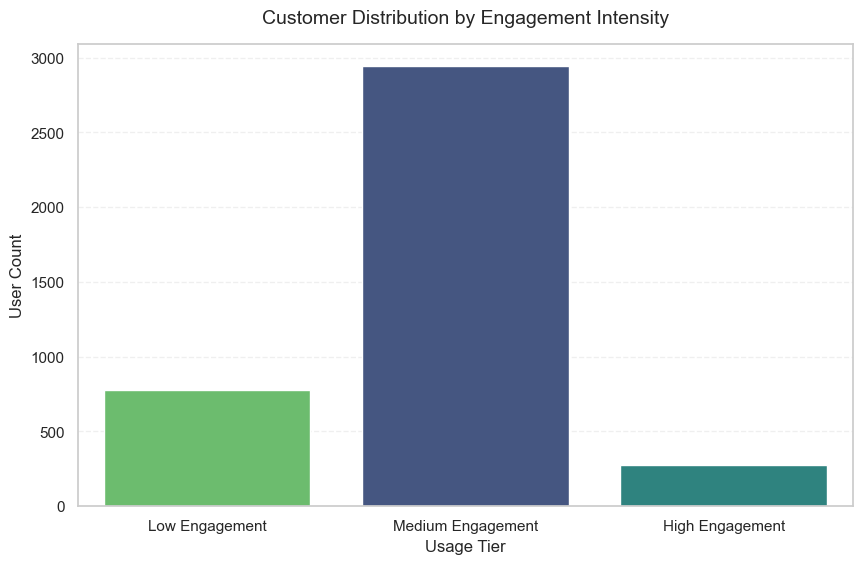

In [48]:
# Visualizing Customer Distribution by Engagement Intensity
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile,
              x='usage_group',
              palette='viridis',
              hue='usage_group',
              legend=False,
              order=['Low Engagement', 'Medium Engagement', 'High Engagement'])

plt.title('Customer Distribution by Engagement Intensity', fontsize=14, pad=15)
plt.xlabel('Usage Tier', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

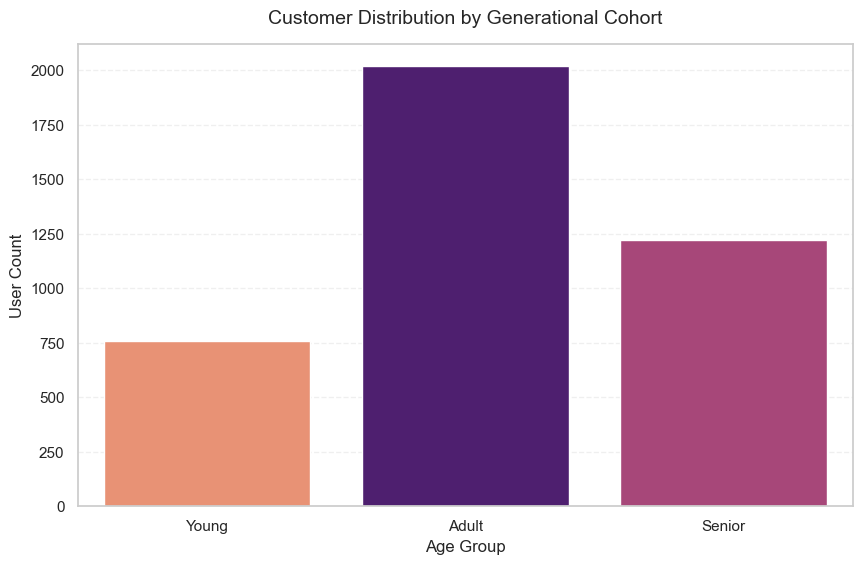

In [49]:
# Visualizing Customer Distribution by Generational Cohort
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile,
              x='age_group',
              palette='magma',
              hue='age_group',
              legend=False,
              order=['Young', 'Adult', 'Senior'])

plt.title('Customer Distribution by Generational Cohort', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


---
# Business Intelligence & Strategic Insights for Stakeholders

This final section synthesizes the core findings of our data audit. Beyond statistical patterns, we focus on **actionable commercial intelligence**—translating data cleaning and segmentation into a roadmap for revenue growth and customer retention at ConnectaTel.

---

## Strategic Executive Summary: ConnectaTel Business Intelligence Report
The following analysis addresses critical data integrity issues, behavioral segmentation, and the untapped monetization opportunities identified within our customer base.

### Data Integrity and Anomaly Detection
Before the strategic analysis, a rigorous data cleaning process was executed to ensure the reliability of the KPIs:

* **Systemic Noise and Nulls**: We identified and remediated critical null values (coded as -999) and date format inconsistencies that previously distorted the network’s usage averages.
* **Messaging Payload Distortion**: The `qty_chars_messages` feature exhibited extreme outliers reaching 2,007 characters (1.4% of the sample). These records tripled the statistical upper bound of 625.50. To stabilize the distribution for future modeling, **Winsorization** was applied at this threshold.
* **Operational Outliers (Voice)**: Approximately 2.4% of users (96 records) exceeded the 61.32 minute threshold, with some reaching 155.69 minutes. These were preserved as they represent a valid "Heavy User" segment with specific business value.

### Behavioral and Demographic Segmentation
Our profiling reveals a multi-generational customer base with distinct engagement patterns:

**Generational Cohorts:**
* **Established Adults (30-59 years)**: The primary group with **2,018 users**. This segment represents the core of the company's fixed revenue and shows the most stable behavior.
* **Senior Citizens (60+ years)**: A robust segment of **1,222 users**. Contrary to common technological stereotypes, they maintain a high and consistent reliance on voice services.
* **Young Adults (<30 years)**: The smallest segment (**760 users**), yet they act as the main drivers for high-density messaging and data payload.

**Engagement Intensity Tiers:**
* **Standard Engagement (73.6%)**: The vast majority (**2,943 users**) consumes within predictable and manageable network ranges.
* **Low Engagement (19.5%)**: **778 users** who currently do not fully utilize their plan’s basic benefits, representing a potential churn risk due to perceived lack of value.
* **High Engagement (7.0%)**: A select group of **279 "Power Users"** who frequently exceed call and message thresholds.

### Strategic Diagnosis: The "Plan-Usage" Gap
The analysis confirms a **behavioral convergence** between the Basic (Surf) and Premium (Ultimate) plans. Statistical dispersion and median values show that a significant portion of users in the Basic Plan maintain the same usage intensity as those in the Premium Plan.

**Conclusion**: This indicates a **missed monetization opportunity**. High-intensity users currently on the Basic Plan are prime candidates for an upgrade, as their consumption habits already align with the Premium tier.

### Strategic Recommendations
* **Targeted Up-selling**: Deploy personalized migration campaigns for "High Engagement" users within the Basic Plan. The value proposition should focus on the **potential savings** by avoiding overage charges.
* **Dynamic Content Packages**: Based on the messaging outliers, ConnectaTel should introduce "Extended Character Bundles" for users consistently hitting the Winsorization cap, transforming a technical anomaly into a revenue stream.
* **Retention and Loyalty**: Implement loyalty programs specifically for the **Adult cohort (30-59)**. Representing over 50% of the active base, their retention is critical for maintaining long-term financial stability.